Streaming Hours: [ 1  1  1  3  5  5  6  7  7  8  9 10]
Monthly Income (USD): [108  81  99 249 553 547 604 768 728 748 922 942]

Mean of streaming hours: 5.25
Mean of monthly income: 529.08

Slope (m): 99.78
Intercept (b): 5.24

Manual Predictions (First 3):
[105.01814059 105.01814059 105.01814059]

R-squared Score: 0.9823
Mean Squared Error: 1651.30


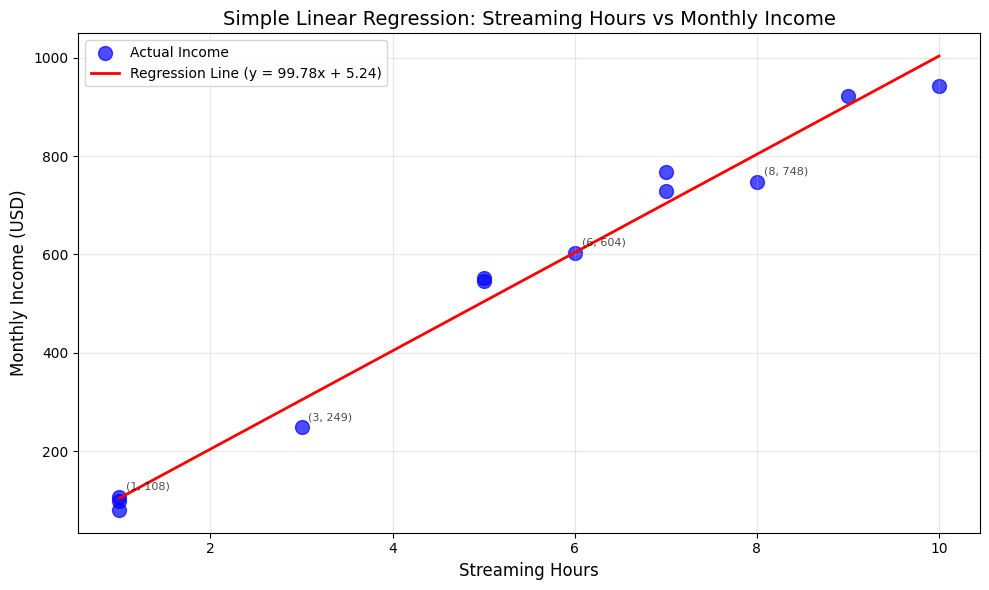


--- Prediction Example ---
If a streamer streams 6.5 hours:
Predicted monthly income: $653.81
Manual predicted monthly income: $653.81

Residuals (Actual - Predicted):


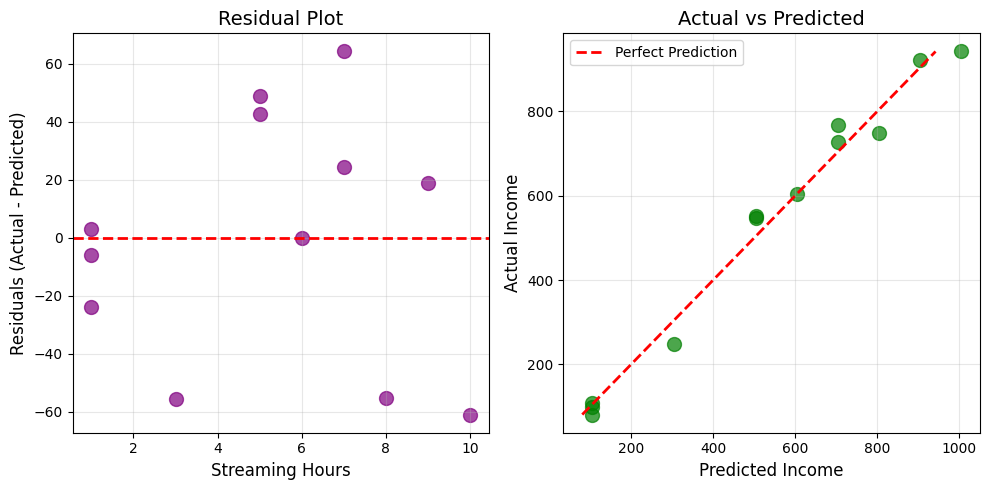

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Fixed streaming hours vs Monthly income (USD)
stream_hours = np.array([1, 1, 1, 3, 5, 5, 6, 7, 7, 8, 9, 10])
monthly_income = np.array([108, 81, 99, 249, 553, 547, 604, 768, 728, 748, 922, 942])

print("Streaming Hours:", stream_hours)
print("Monthly Income (USD):", monthly_income)

# Calculate means
x_mean = np.mean(stream_hours)
y_mean = np.mean(monthly_income)

print(f"\nMean of streaming hours: {x_mean:.2f}")
print(f"Mean of monthly income: {y_mean:.2f}")

# Calculate slope (m) and intercept (b)
numerator = np.sum((stream_hours - x_mean) * (monthly_income - y_mean))
denominator = np.sum((stream_hours - x_mean) ** 2)

slope = numerator / denominator
intercept = y_mean - slope * x_mean

print(f"\nSlope (m): {slope:.2f}")
print(f"Intercept (b): {intercept:.2f}")

# Make predictions
predictions_manual = slope * stream_hours + intercept

print("\nManual Predictions (First 3):")
print(predictions_manual[:3])

# Calculate R-squared
ss_total = np.sum((monthly_income - y_mean) ** 2)
ss_residual = np.sum((monthly_income - predictions_manual) ** 2)
r_squared = 1 - (ss_residual / ss_total)

print(f"\nR-squared Score: {r_squared:.4f}")

# Calculate MSE
mse_manual = np.mean((monthly_income - predictions_manual) ** 2)
print(f"Mean Squared Error: {mse_manual:.2f}")



# Create scatter plot with regression line
plt.figure(figsize=(10, 6))

# Plot actual data points
plt.scatter(stream_hours, monthly_income, color='blue', s=100, 
            label='Actual Income', alpha=0.7)

# Plot regression line
plt.plot(stream_hours, predictions_manual, color='red', 
         linewidth=2, label=f'Regression Line (y = {slope:.2f}x + {intercept:.2f})')

# Add labels and title
plt.xlabel('Streaming Hours', fontsize=12)
plt.ylabel('Monthly Income (USD)', fontsize=12)
plt.title('Simple Linear Regression: Streaming Hours vs Monthly Income', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Annotate some points
for i in range(0, len(stream_hours), 3):
    plt.annotate(f'({stream_hours[i]}, {monthly_income[i]})', 
                 xy=(stream_hours[i], monthly_income[i]),
                 xytext=(5, 5), textcoords='offset points', 
                 fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

# Predict monthly income for a streamer who streams 6.5 hours
new_hours = np.array([6.5])
predicted_income = slope * new_hours + intercept

print(f"\n--- Prediction Example ---")
print(f"If a streamer streams {new_hours[0]} hours:")
print(f"Predicted monthly income: ${predicted_income[0]:.2f}")

# Using sklearn model
predicted_manual = slope * new_hours + intercept
print(f"Manual predicted monthly income: ${predicted_manual[0]:.2f}")

# Calculate residuals (errors)
residuals = monthly_income - predictions_manual
print("\nResiduals (Actual - Predicted):")

# Plot residuals
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(stream_hours, residuals, color='purple', s=100, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Streaming Hours', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.title('Residual Plot', fontsize=14)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(predictions_manual, monthly_income, color='green', s=100, alpha=0.7)
plt.plot([monthly_income.min(), monthly_income.max()], 
         [monthly_income.min(), monthly_income.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Predicted Income', fontsize=12)
plt.ylabel('Actual Income', fontsize=12)
plt.title('Actual vs Predicted', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()